# Reading GDEX THREDDS Data with xarray

---

## Overview

xarray can open remote OPeNDAP datasets directly from the GDEX THREDDS server, enabling lazy, memory-efficient access without downloading files.

1. Construct an OPeNDAP URL from the TDS catalog
2. Open the dataset lazily with xarray
3. Select a spatial and temporal subset
4. Plot the result

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| tds_intro | Necessary | GDEX TDS catalog and OPeNDAP concept |
| [xarray](https://xarray.pydata.org) | Necessary | |
| [matplotlib](https://matplotlib.org) / [cartopy](https://scitools.org.uk/cartopy) | Helpful | Visualization |

- **Time to learn**: 20 minutes

---

## Imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

## Building an OPeNDAP URL

OPeNDAP URLs on the GDEX TDS follow the pattern:
`https://thredds.rda.ucar.edu/thredds/dodsC/<path-to-file>`

In [2]:
# Construct the OPeNDAP URL for your target file
OPeNDAP_URL = (
    "https://thredds.rda.ucar.edu/thredds/dodsC/"
    "files/g/d633000/e5.oper.an.pl/202001/"
    "e5.oper.an.pl.128_130_t.ll025sc.2020010100_2020010123.nc"
)

## Lazy Loading with xarray

xarray opens remote OPeNDAP datasets without downloading the full file. Data is fetched on demand when you call `.load()` or compute.

In [3]:
import os
import psutil
# check the memory usage of the current notebook process only
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 2):.2f} MB (RSS)")

Notebook process memory usage: 170.79 MB (RSS)


In [4]:
import xarray as xr
# Open the remote dataset
ds_lazy = xr.open_dataset(OPeNDAP_URL, engine="netcdf4", chunks={})
ds_lazy

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 24, level: 37, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 192B 2020-01-01 ... 2020-01-01T23:00:00
  * level      (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    utc_date   (time) int32 96B dask.array<chunksize=(24,), meta=np.ndarray>
    T          (time, level, latitude, longitude) float32 4GB dask.array<chunksize=(24, 37, 721, 1440), meta=np.ndarray>
Attributes:
    DATA_SOURCE:                     ECMWF: https://cds.climate.copernicus.eu...
    NETCDF_CONVERSION:               CISL RDA: Conversion from ECMWF GRIB 1 d...
    NETCDF_VERSION:                  4.7.3
    CONVERSION_PLATFORM:             Linux r1i2n8 4.12.14-95.37.1.18642.1.PTF...
    CONVERSION_DATE:                 Fri Apr  3 10:12:54 MDT 2020
    Conventions:                     CF-1.6
    NETCDF_COMPRESSION:              NCO: Precision-preserving compression to...
    history:                         Fri Apr  3 10:13:12 2020: ncks -4 --ppc ...
    NCO:                             netCDF Operators version 4.7.9 (Homepage...
    DODS_EXTRA.Unlimited_Dimension:  time

In [5]:
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 2):.2f} MB (RSS)")

Notebook process memory usage: 203.95 MB (RSS)


In [6]:
# Open the remote dataset
ds_load = xr.open_dataset(OPeNDAP_URL, engine="netcdf4").isel(time=0).load()
ds_load

<xarray.Dataset> Size: 154MB
Dimensions:    (level: 37, latitude: 721, longitude: 1440)
Coordinates:
  * level      (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2020-01-01
Data variables:
    utc_date   int32 4B 2020010100
    T          (level, latitude, longitude) float32 154MB 265.0 265.0 ... 264.2
Attributes:
    DATA_SOURCE:                     ECMWF: https://cds.climate.copernicus.eu...
    NETCDF_CONVERSION:               CISL RDA: Conversion from ECMWF GRIB 1 d...
    NETCDF_VERSION:                  4.7.3
    CONVERSION_PLATFORM:             Linux r1i2n8 4.12.14-95.37.1.18642.1.PTF...
    CONVERSION_DATE:                 Fri Apr  3 10:12:54 MDT 2020
    Conventions:                     CF-1.6
    NETCDF_COMPRESSION:              NCO: Precision-preserving compression to...
    history:                         Fri Apr  3 10:13:12 2020: ncks -4 --ppc ...
    NCO:                             netCDF Operators version 4.7.9 (Homepage...
    DODS_EXTRA.Unlimited_Dimension:  time

In [7]:
mem_info = process.memory_info()
print(f"Notebook process memory usage: {mem_info.rss / (1024 ** 2):.2f} MB (RSS)")

Notebook process memory usage: 508.82 MB (RSS)


:::{tip} Memory: Lazy vs. Eager Loading
Notice the difference in memory consumption between the two approaches:

- **`ds_lazy`** (lazy loading the full 4 GB dataset): only **~30 MB** of memory is used, because xarray fetches only the metadata and defers actual data retrieval.
- **`ds_load`** (eagerly loading a single time step with `.load()`): consumes **~300 MB** of memory, as the temperature field (`T`) for one time step across all pressure levels and the full global grid (~154 MB of float32 data) is actually transferred and held in memory.

This demonstrates the power of lazy evaluation — you can open a multi-gigabyte remote dataset and inspect its structure, coordinates, and variables without downloading anything until you explicitly request it.
:::

## Selecting a Subset and Plotting
In this section, we subset temperature from the **lazy-loaded** dataset (`ds_lazy`) over a USA domain and visualize two pressure levels at the first time step.

- **Region**: roughly CONUS (`latitude: 55 → 20`, `longitude: 230 → 300` in 0–360 coordinates)
- **Time**: first analysis hour (`time=0`)
- **Levels to compare**:
    - **1000 hPa** (lowest model pressure level; near-surface pattern)
    - **500 hPa** (upper-air/mid-tropospheric pattern)

This demonstrates that with lazy loading, xarray only fetches the selected subset and levels needed for plotting, not the full global 4 GB field.

/glade/derecho/scratch/chiaweih/tmp/ipykernel_123346/1146481999.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


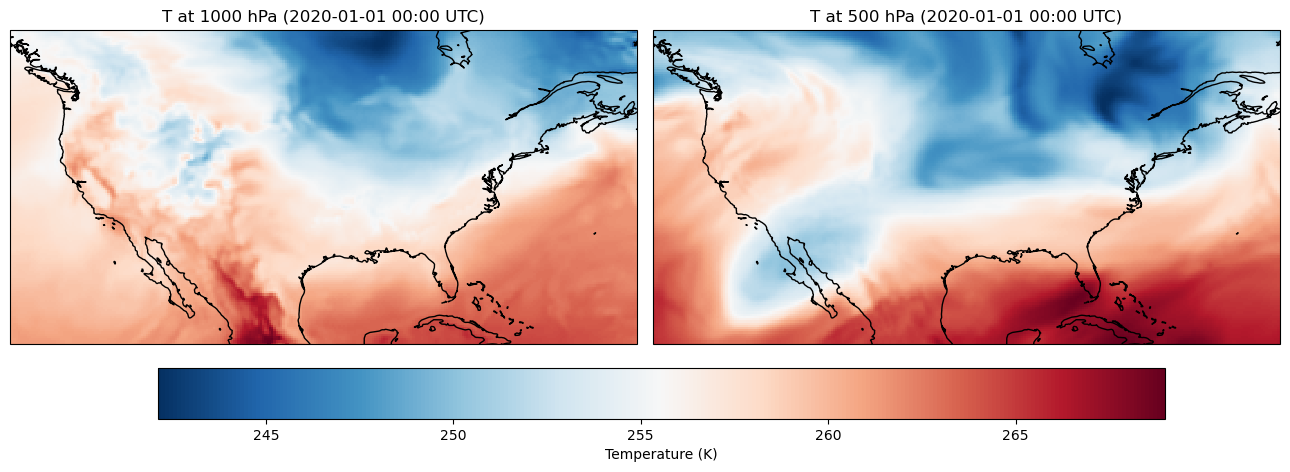

In [10]:
# Subset from lazy dataset: CONUS-like box, first time step, two pressure levels
subset = ds_lazy["T"].isel(time=0).sel(
    level=[1000, 500],
    latitude=slice(55, 20),
    longitude=slice(230, 300),
)

fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, lev in zip(axes, [1000, 500]):
    da = subset.sel(level=lev)
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_extent([230, 300, 20, 55], crs=ccrs.PlateCarree())
    ax.set_title(f"T at {lev} hPa (time=0)")

fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.08, label="Temperature (K)")
plt.tight_layout()
# Use RdBu_r colormap on both panels (and linked colorbar mappable)
for a in axes:
    if a.collections:
        a.collections[0].set_cmap("RdBu_r")
im.set_cmap("RdBu_r")

# Put actual datetime in titles
time_str = subset.time.dt.strftime("%Y-%m-%d %H:%M UTC").item()
for a, lev in zip(axes, subset.level.values):
    a.set_title(f"T at {int(lev)} hPa ({time_str})")

# Move colorbar down to avoid overlap
fig.subplots_adjust(bottom=0.18)
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 - 0.1, pos.width, pos.height])

plt.show()

---

## Summary

xarray's OPeNDAP support turns GDEX THREDDS into a remote analysis environment — no local copy needed. Lazy evaluation means you only fetch the data you actually use.

### What's next?

See `zarr_intro.ipynb` for cloud-optimized Zarr access, which is often faster for large array operations.

## Resources and References

- [xarray OPeNDAP docs](https://docs.xarray.dev/en/stable/user-guide/io.html#opendap)
- [GDEX THREDDS Catalog](https://thredds.rda.ucar.edu/thredds/catalog.html)
- [cartopy documentation](https://scitools.org.uk/cartopy/docs/latest/)